## 1. Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Get data

In [2]:
# Read datasets
df_polaris = pd.read_csv('01_polaris_hotline_signals_fy2013_2024.csv')
df_ovc = pd.read_csv('02_ovc_victims_served_fy23_fy24.csv')
df_ctdc_year = pd.read_csv('03_ctdc_global_by_year_exploitation_type.csv')
df_ctdc_means = pd.read_csv('04_ctdc_means_of_control_by_exploitation.csv')
df_ctdc_top_30_countries = pd.read_csv('05_ctdc_top30_countries_of_exploitation.csv')
df_ctdc_age_gender = pd.read_csv('06_ctdc_age_gender_exploitation_crosstab.csv')
df_global_dataset = pd.read_csv('The Global Dataset 14 Apr 2020.csv', low_memory=False)

In [3]:
# Explore shapes
print('Initial shape polaris: ',df_polaris.shape )
print('Initial shape ovc: ',df_ovc.shape )
print('Initial shape ctdc by year: ',df_ctdc_year.shape )
print('Initial shape ctdc by mean: ',df_ctdc_means.shape )
print('Initial shape ctdc by top 30 countries: ',df_ctdc_top_30_countries.shape )
print('Initial shape ctdc by age and gender: ',df_ctdc_age_gender.shape )
print('Initial shape global dataset: ',df_global_dataset.shape )

Initial shape polaris:  (12, 5)
Initial shape ovc:  (8, 8)
Initial shape ctdc by year:  (18, 16)
Initial shape ctdc by mean:  (32, 6)
Initial shape ctdc by top 30 countries:  (30, 6)
Initial shape ctdc by age and gender:  (18, 7)
Initial shape global dataset:  (48801, 64)


In [4]:
print('Head polaris:')
display(df_polaris.head(3))

print('Head ovc:')
display(df_ovc.head(3))

print('Head ctdc by year:')
display(df_ctdc_year.head(3))

print('Head ctdc means:')
display(df_ctdc_means.head(3))

print('Head ctdc top 30 countries age and gender:')
display(df_ctdc_top_30_countries.head(3))

print('Head ctdc age and gender:')
display(df_ctdc_age_gender.head(3))

print('Head global dataset:')
display(df_global_dataset.head(3))

Head polaris:


,fiscal_year,total_signals,substantive_signals,signals_from_potential_victims,potential_situations_identified
0,2013,32438,NaN,2641,4796
1,2014,39134,NaN,2602,5166
2,2015,36916,NaN,3487,5418


Head ovc:


,fiscal_year,quarter,sex_trafficking,labor_trafficking,eligible_family_members,undetermined,sex_and_labor,quarterly_total
0,2024,Q1,2429,614,564,368,296,4271
1,2024,Q2,2385,659,492,268,261,4065
2,2024,Q3,2262,571,486,224,223,3766


Head ctdc by year:


...

,CountryOfExploitation,n_records,n_female,n_male,n_forced_labour,n_sexual_exploit
0,US,12512,12168,344,197,11855
1,UA,5399,2941,2458,54,55
2,MD,4504,3615,889,0,77


Head ctdc age and gender:


,ageBroad,gender,n,n_forced_labour,n_sexual_exploit,n_forced_labour_obs,n_sexual_exploit_obs
0,0--8,Female,841,101,122,223,211
1,0--8,Male,715,121,36,157,157
2,18--20,Female,4227,256,2906,3237,3238


Head global dataset:


,By using this data you agree to the Terms of Use: https://www.ctdatacollaborative.org/terms-use,yearOfRegistration,Datasource,gender,ageBroad,majorityStatus,majorityStatusAtExploit,majorityEntry,citizenship,meansOfControlDebtBondage,...,typeOfSexPrivateSexualServices,typeOfSexConcatenated,isAbduction,RecruiterRelationship,CountryOfExploitation,recruiterRelationIntimatePartner,recruiterRelationFriend,recruiterRelationFamily,recruiterRelationOther,recruiterRelationUnknown
0,NaN,2002,Case Management,Female,18--20,Adult,-99,-99,CO,-99,...,-99,-99,-99,-99,-99,0,0,0,0,1
1,NaN,2002,Case Management,Female,18--20,Adult,-99,-99,CO,-99,...,-99,-99,-99,-99,-99,0,0,0,0,1
2,NaN,2002,Case Management,Female,18--20,Adult,-99,-99,CO,-99,...,-99,-99,-99,-99,-99,0,0,0,0,1


## 2. Explore polaris dataset

In [5]:
df_polaris.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   fiscal_year                      12 non-null     int64  
 1   total_signals                    12 non-null     int64  
 2   substantive_signals              7 non-null      float64
 3   signals_from_potential_victims   12 non-null     int64  
 4   potential_situations_identified  12 non-null     int64  
dtypes: float64(1), int64(4)
memory usage: 612.0 bytes


In [6]:
# Total number of rows
total_rows = df_polaris.shape[0]
# Get null total number of null values by column
df_aux = df_polaris.isna().sum()
# Transfrom to dataframe
df_aux = df_aux.to_frame()
df_aux = df_aux.rename(columns={0: "Missing"})
df_aux.reset_index(inplace=True)
df_aux['%missing_value'] = round((df_aux['Missing'] / total_rows)*100,0)
df_aux

,index,Missing,%missing_value
0,fiscal_year,0,0.0
1,total_signals,0,0.0
2,substantive_signals,5,42.0
3,signals_from_potential_victims,0,0.0
4,potential_situations_identified,0,0.0


Almost have of the substantive_signals have missing values in the dataset, the other columns don't present missing information.

In [7]:
print('Number of years in the dataset: ',df_polaris['fiscal_year'].nunique())
print('Years: ',df_polaris['fiscal_year'].unique() )

Number of years in the dataset:  12
Years:  [2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]


In [8]:
# Calculate the percentage of signals report by victims
df_polaris['signals_victims_percentage'] = round(df_polaris['signals_from_potential_victims'] / df_polaris['total_signals'],4)*100
# Calculte the the average number of a single trafficking situation generate by multiple signals.
df_polaris['avg_signals_identified'] =  df_polaris['total_signals'] / df_polaris['potential_situations_identified']

In [9]:
display(df_polaris.head(3))

,fiscal_year,total_signals,substantive_signals,signals_from_potential_victims,potential_situations_identified,signals_victims_percentage,avg_signals_identified
0,2013,32438,NaN,2641,4796,8.14,6.763553
1,2014,39134,NaN,2602,5166,6.65,7.575300
2,2015,36916,NaN,3487,5418,9.45,6.813584


In [10]:
df_polaris.head(50)

,fiscal_year,total_signals,substantive_signals,signals_from_potential_victims,potential_situations_identified,signals_victims_percentage,avg_signals_identified
0,2013,32438,NaN,2641,4796,8.14,6.763553
1,2014,39134,NaN,2602,5166,6.65,7.575300
2,2015,36916,NaN,3487,5418,9.45,6.813584
3,2016,54823,NaN,4608,7405,8.41,7.403511
4,2017,68938,NaN,4626,8686,6.71,7.936680
5,2018,116940,47709.0,7136,10658,6.10,10.972040
6,2019,136990,56644.0,10362,11852,7.56,11.558387
7,2020,195100,65959.0,13129,11193,6.73,17.430537
8,2021,219380,66308.0,13538,10983,6.17,19.974506
9,2022,212167,55731.0,10190,10013,4.80,21.189154


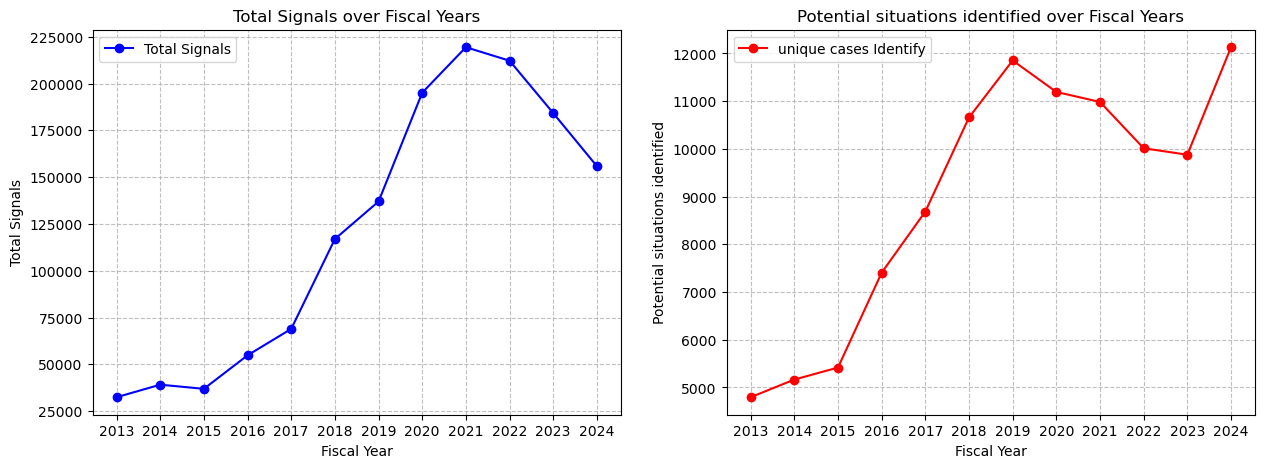

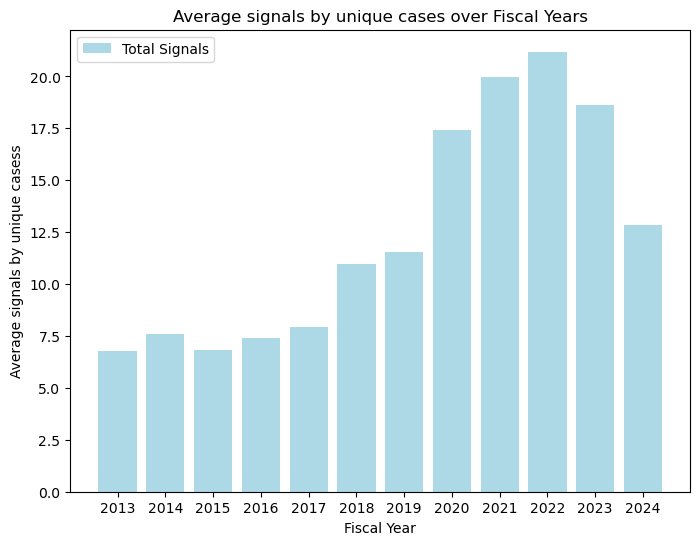

In [11]:
# Graph 1: Create the time series plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.plot(df_polaris['fiscal_year'], df_polaris['total_signals'], marker='o', linestyle='-', color='b', label='Total Signals')
# Add labels and title
ax1.set_title('Total Signals over Fiscal Years')
ax1.set_xlabel('Fiscal Year')
ax1.set_ylabel('Total Signals')
ax1.set_xticks(df_polaris['fiscal_year']) 
ax1.grid(True, linestyle='--', alpha=0.8)
ax1.legend()

ax2.plot(df_polaris['fiscal_year'], df_polaris['potential_situations_identified'], marker='o', linestyle='-', color='red', label='unique cases Identify')
# Add labels and title
ax2.set_title('Potential situations identified over Fiscal Years')
ax2.set_xlabel('Fiscal Year')
ax2.set_ylabel('Potential situations identified')
ax2.set_xticks(df_polaris['fiscal_year']) 
ax2.grid(True, linestyle='--', alpha=0.8)
ax2.legend()
plt.show()


# Graph 2: avg_signals_by_unique_cases
plt.figure(figsize=(8, 6)) 
plt.bar(df_polaris['fiscal_year'], df_polaris['avg_signals_identified'], color='lightblue', label='Total Signals')

# Add labels and title
plt.title('Average signals by unique cases over Fiscal Years')
plt.xlabel('Fiscal Year')
plt.ylabel('Average signals by unique casess')
plt.xticks(df_polaris['fiscal_year']) 
plt.legend()
plt.show()


The timeseries plot shows that the Total Signals have been increasing since 2013 until 2021, with a downward trend from 2021 to 2024. However, the potential situations identified got their highest value in 2024, with 12K victims found, despite a negative trend from 2019 to 2023, probably related to the COVID period. Moreover, we can see that the average signals by case have been between 7.5 to 20, meaning that several people report the same human traffic case. 

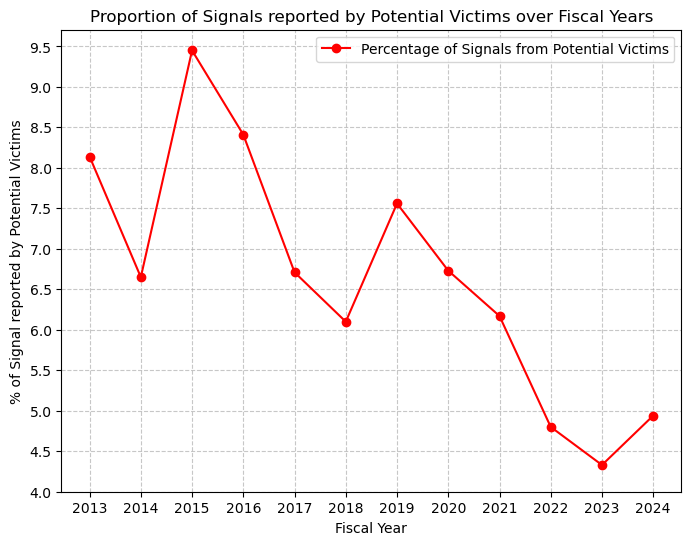

In [12]:
# Graph 2: Create the time series plot
plt.figure(figsize=(8, 6)) 
plt.plot(df_polaris['fiscal_year'], df_polaris['signals_victims_percentage'], marker='o', linestyle='-', color='r', label='Percentage of Signals from Potential Victims')
# Add labels and title
plt.title('Proportion of Signals reported by Potential Victims over Fiscal Years')
plt.xlabel('Fiscal Year')
plt.ylabel('% of Signal reported by Potential Victims')
plt.xticks(df_polaris['fiscal_year']) 
plt.yticks(np.arange(4, 10, 0.5))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

The proportion of signals reported by potential victims has constantly decreased over the last decade, reaching a minimum of 5%. This timeseries plot suggests that the victims have been less listened to, depending more on witnesses, family, friends, law enforcement, or anonymous reporters.

## 3. Explore ovc dataset

In [13]:
df_ovc.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   fiscal_year              8 non-null      int64
 1   quarter                  8 non-null      str  
 2   sex_trafficking          8 non-null      int64
 3   labor_trafficking        8 non-null      int64
 4   eligible_family_members  8 non-null      int64
 5   undetermined             8 non-null      int64
 6   sex_and_labor            8 non-null      int64
 7   quarterly_total          8 non-null      int64
dtypes: int64(7), str(1)
memory usage: 644.0 bytes


We don't have missing values

In [14]:
# Combine columns
df_ovc['fiscal_year'] = df_ovc['fiscal_year'].astype(str)
df_ovc['fiscal_year_quarter'] = df_ovc['fiscal_year'] + df_ovc['quarter']
df_ovc = df_ovc.sort_values(by='fiscal_year_quarter')

In [15]:
df_ovc.head(10)

,fiscal_year,quarter,sex_trafficking,labor_trafficking,eligible_family_members,undetermined,sex_and_labor,quarterly_total,fiscal_year_quarter
4,2023,Q1,1823,532,500,109,182,3146,2023Q1
5,2023,Q2,1971,610,558,208,84,3431,2023Q2
6,2023,Q3,2000,463,414,128,190,3195,2023Q3
7,2023,Q4,1892,451,425,201,178,3147,2023Q4
0,2024,Q1,2429,614,564,368,296,4271,2024Q1
1,2024,Q2,2385,659,492,268,261,4065,2024Q2
2,2024,Q3,2262,571,486,224,223,3766,2024Q3
3,2024,Q4,1990,559,468,325,197,3539,2024Q4


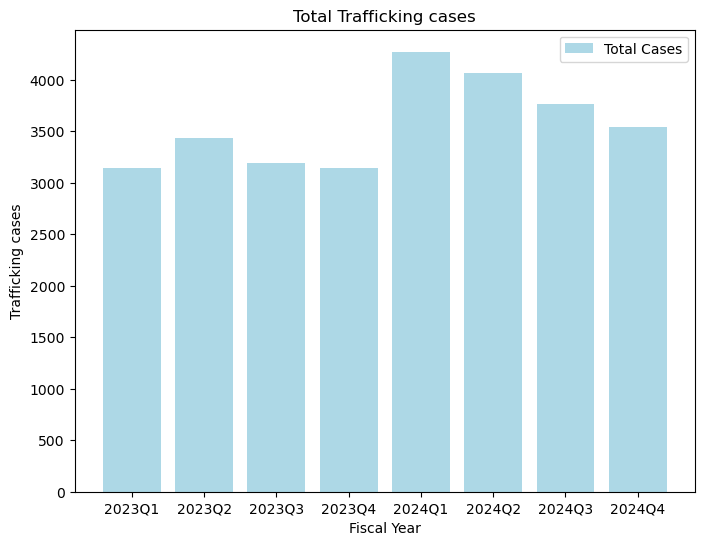

In [16]:
# Graph 2: avg_signals_by_unique_cases
plt.figure(figsize=(8, 6)) 
plt.bar(df_ovc['fiscal_year_quarter'], df_ovc['quarterly_total'], color='lightblue', label='Total Cases')

# Add labels and title
plt.title('Total Trafficking cases')
plt.xlabel('Fiscal Year')
plt.ylabel('Trafficking cases')
plt.legend()
plt.show()

From the 2023 and 2024 quarter trafficking cases, we don't see any strong seasonality trend in the data, but Q1 and Q2 tend to have more cases compared to the last semester of the year. In addition, we can see an increase in the number of cases in 2024.

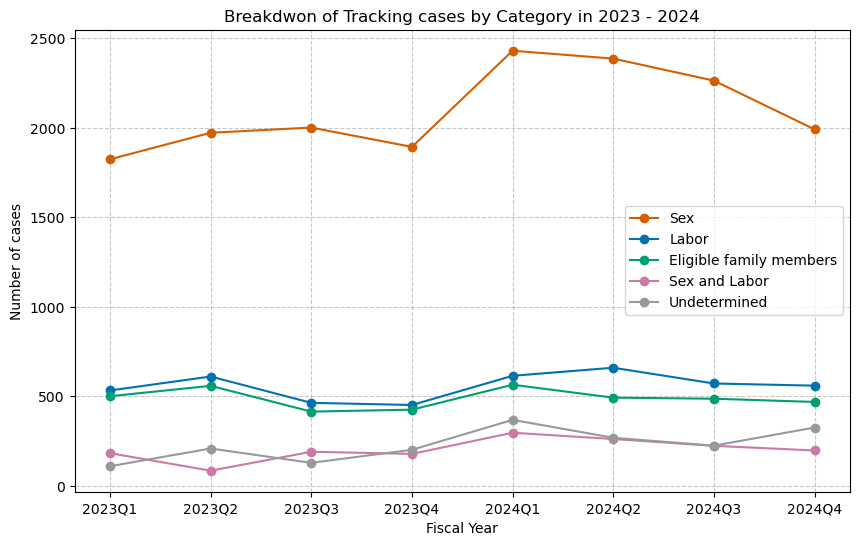

In [17]:
# Create plot
plt.figure(figsize=(10, 6)) 
plt.plot(df_ovc['fiscal_year_quarter'], df_ovc['sex_trafficking'], marker='o', linestyle='-', color='#D55E00', label='Sex')
plt.plot(df_ovc['fiscal_year_quarter'], df_ovc['labor_trafficking'], marker='o', linestyle='-', color='#0072B2', label='Labor')
plt.plot(df_ovc['fiscal_year_quarter'], df_ovc['eligible_family_members'], marker='o', linestyle='-', color='#009E73', label='Eligible family members')
plt.plot(df_ovc['fiscal_year_quarter'], df_ovc['sex_and_labor'], marker='o', linestyle='-', color='#CC79A7', label='Sex and Labor')
plt.plot(df_ovc['fiscal_year_quarter'], df_ovc['undetermined'], marker='o', linestyle='-', color='#999999', label='Undetermined')


# Add labels and title
plt.title('Breakdwon of Tracking cases by Category in 2023 - 2024')
plt.xlabel('Fiscal Year')
plt.ylabel('Number of cases')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

The Sex category is by far the biggest reason for Tracking with 2000-2500 cases around by quarter, followed by Labor with aprox 500-600 victims each quarter, Eligibile family members have a similar behavior with the same average number of victims, and Sex and labor / undetermined represent the lowest category with 250-100 cases on average.

,trafficking_type,2023,2024
1,sex_trafficking,7686,9066
2,labor_trafficking,2056,2403
3,eligible_family_members,1897,2010
4,undetermined,646,1185
5,sex_and_labor,634,977


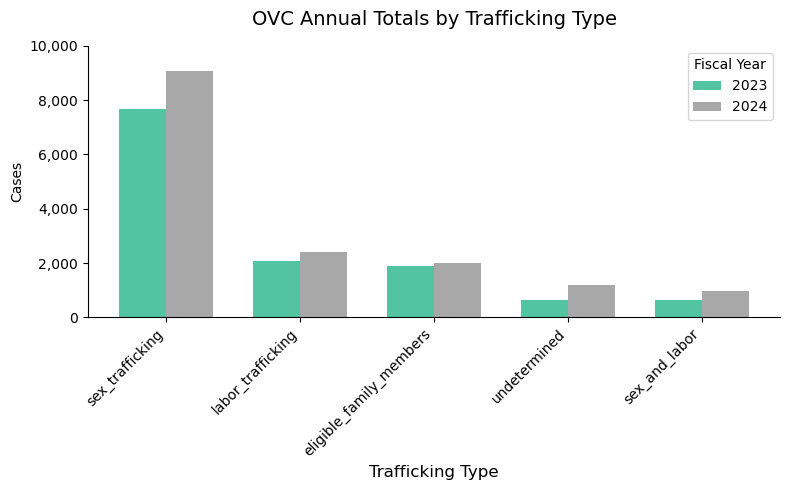

In [18]:
# Create 2023 and 2024 plot
df_aux = df_ovc.groupby(by='fiscal_year')[['sex_trafficking','labor_trafficking','eligible_family_members','undetermined','sex_and_labor']].sum().reset_index()
df_aux = df_aux.T.reset_index()
df_aux.rename(columns={'index':'trafficking_type', 0: '2023', 1: '2024'}, inplace=True)
df_aux = df_aux[df_aux['trafficking_type']!='fiscal_year'] 
display(df_aux)

# --- Data ---
categories = ["sex_trafficking","labor_trafficking","eligible_family_members","undetermined","sex_and_labor"]

# --- Layout ---
x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

# --- Bars ---
bars1 = ax.bar(x - width/2, df_aux['2023'], width, label="2023", color="#52c4a0")  # teal
bars2 = ax.bar(x + width/2, df_aux['2024'], width, label="2024", color="#a8a8a8")  # gray

# --- Styling ---
ax.set_title("OVC Annual Totals by Trafficking Type", fontsize=14, pad=15)
ax.set_xlabel("Trafficking Type", fontsize=12)
ax.set_ylabel("Cases")  # no y-axis label in original
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=45, ha="right", fontsize=10)
ax.set_ylim(0, 10000)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f"{int(val):,}"))

# Remove top and right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# --- Legend ---
ax.legend(title="Fiscal Year", fontsize=10, title_fontsize=10, frameon=True)

plt.tight_layout()
plt.savefig("ovc_trafficking_chart.png", dpi=150)
plt.show()

The OVC displays that in recent years, the most common cause is sex trafficking, with an increase of 15K victims in 2024 compared with 2023, reaching 90K annually, followed by labor trafficking, with 2403 in 2024, in contrast with 2056 in 2023. It is essential that governance start tracking these metrics to develop more efficient public policies that reduce the number of victims.

## 3. Explore ctdc datasets

In [19]:
print('Head ctdc by year:')
display(df_ctdc_year.head(10))

Head ctdc by year:


,year,n_records,n_female,n_male,forced_labour_n,forced_labour_denom,sexual_exploit_n,sexual_exploit_denom,sex_and_labour_n,sex_and_labour_denom,forced_marriage_n,forced_marriage_denom,organ_removal_n,organ_removal_denom,slavery_practices_n,slavery_practices_denom
0,2002,1026,1026,0,0,919,867,919,0,919,0,845,0,919,0,0
1,2003,357,342,15,0,357,357,357,0,357,0,320,0,357,0,0
2,2004,223,223,0,0,223,160,223,0,223,0,223,0,223,0,0
3,2005,1455,1030,425,817,1431,492,1431,0,1431,0,1431,0,1431,0,0
4,2006,1423,1134,289,622,1181,318,1078,0,1078,0,1078,0,1078,0,0
5,2007,1417,1072,345,251,563,344,563,0,563,0,563,0,563,0,0
6,2008,802,640,162,66,104,23,61,0,61,0,61,0,61,0,0
7,2009,587,511,76,15,51,0,51,0,51,0,0,0,51,0,0
8,2010,943,478,465,260,271,38,275,0,248,0,0,0,248,0,0
9,2011,1340,798,542,193,193,0,168,0,168,0,0,0,168,0,0


In [20]:
df_ctdc_year.info()

<class 'pandas.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   year                     18 non-null     int64
 1   n_records                18 non-null     int64
 2   n_female                 18 non-null     int64
 3   n_male                   18 non-null     int64
 4   forced_labour_n          18 non-null     int64
 5   forced_labour_denom      18 non-null     int64
 6   sexual_exploit_n         18 non-null     int64
 7   sexual_exploit_denom     18 non-null     int64
 8   sex_and_labour_n         18 non-null     int64
 9   sex_and_labour_denom     18 non-null     int64
 10  forced_marriage_n        18 non-null     int64
 11  forced_marriage_denom    18 non-null     int64
 12  organ_removal_n          18 non-null     int64
 13  organ_removal_denom      18 non-null     int64
 14  slavery_practices_n      18 non-null     int64
 15  slavery_practices_d

In [21]:
# Filter 2019, since the information is not totally complete
df_ctdc_year = df_ctdc_year[df_ctdc_year['year']<2019]
print('Number of years in the dataset: ',df_ctdc_year['year'].nunique())
print('Years: ',df_ctdc_year['year'].unique() )

Number of years in the dataset:  17
Years:  [2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015
 2016 2017 2018]


In [22]:
df_ctdc_year.head(5)

,year,n_records,n_female,n_male,forced_labour_n,forced_labour_denom,sexual_exploit_n,sexual_exploit_denom,sex_and_labour_n,sex_and_labour_denom,forced_marriage_n,forced_marriage_denom,organ_removal_n,organ_removal_denom,slavery_practices_n,slavery_practices_denom
0,2002,1026,1026,0,0,919,867,919,0,919,0,845,0,919,0,0
1,2003,357,342,15,0,357,357,357,0,357,0,320,0,357,0,0
2,2004,223,223,0,0,223,160,223,0,223,0,223,0,223,0,0
3,2005,1455,1030,425,817,1431,492,1431,0,1431,0,1431,0,1431,0,0
4,2006,1423,1134,289,622,1181,318,1078,0,1078,0,1078,0,1078,0,0


Historical numebr of cases from 2002 to 2018
Total female 35,506 with a 72.80% percentage of the total observations between 2002 and 2018
Total male 13,267 with a 27.20% percentage of the total observations between 2002 and 2018


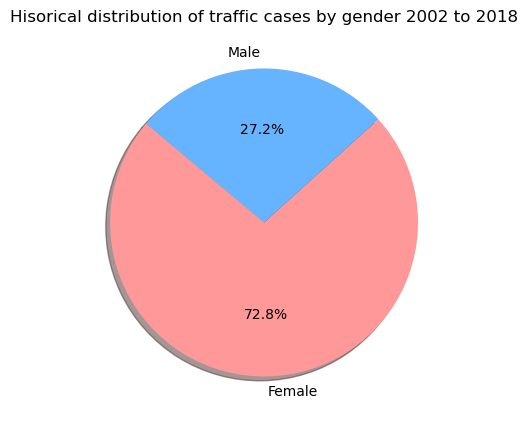

In [23]:
# Check the distribution of n_feamle and n_male
total_cases = df_ctdc_year['n_records'].sum()
total_female = df_ctdc_year['n_female'].sum()
total_male = df_ctdc_year['n_male'].sum()
print('Historical numebr of cases from 2002 to 2018')
print('Total female {:,} with a {:.2%} percentage of the total observations between 2002 and 2018'.format(total_female, total_female/total_cases))
print('Total male {:,} with a {:.2%} percentage of the total observations between 2002 and 2018'.format(total_male, total_male/total_cases))

plt.figure(figsize=(5, 5)) # Set the figure size
colors = ['#ff9999', '#66b3ff']
plt.pie([total_female, total_male], labels=['Female', 'Male'], colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
plt.title('Hisorical distribution of traffic cases by gender 2002 to 2018')
plt.show()

In [24]:
# Historical evolution of gender distribution
df_ctdc_year['n_female%'] = round(df_ctdc_year['n_female'] / df_ctdc_year['n_records'],2)*100
df_ctdc_year['n_male%'] = round(df_ctdc_year['n_male'] / df_ctdc_year['n_records'],2)*100
display(df_ctdc_year[['year','n_records','n_female','n_male','n_female%','n_male%']])

,year,n_records,n_female,n_male,n_female%,n_male%
0,2002,1026,1026,0,100.0,0.0
1,2003,357,342,15,96.0,4.0
2,2004,223,223,0,100.0,0.0
3,2005,1455,1030,425,71.0,29.0
4,2006,1423,1134,289,80.0,20.0
5,2007,1417,1072,345,76.0,24.0
6,2008,802,640,162,80.0,20.0
7,2009,587,511,76,87.0,13.0
8,2010,943,478,465,51.0,49.0
9,2011,1340,798,542,60.0,40.0


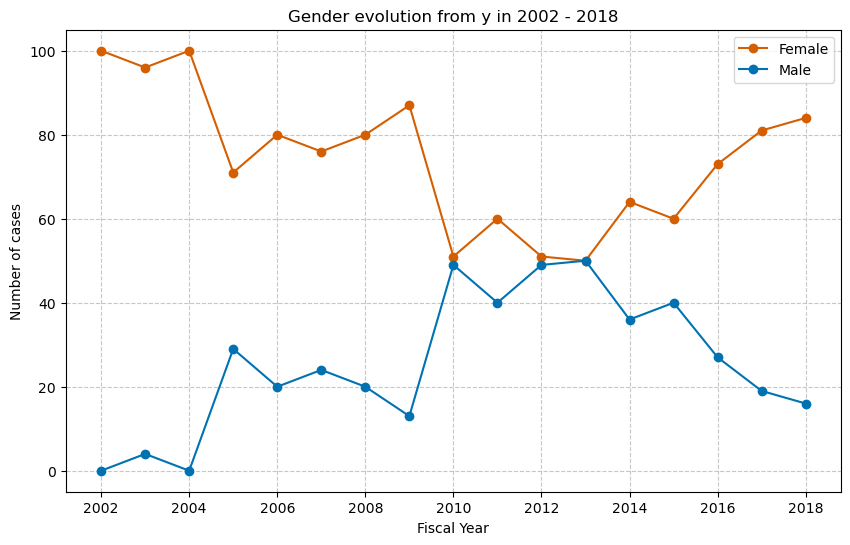

In [25]:
# Create plot
plt.figure(figsize=(10, 6)) 
plt.plot(df_ctdc_year['year'], df_ctdc_year['n_female%'], marker='o', linestyle='-', color='#D55E00', label='Female')
plt.plot(df_ctdc_year['year'], df_ctdc_year['n_male%'], marker='o', linestyle='-', color='#0072B2', label='Male')

# Add labels and title
plt.title('Gender evolution from y in 2002 - 2018')
plt.xlabel('Fiscal Year')
plt.ylabel('Number of cases')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

Historically, it is clear that women have been more exploited on average from 2002 to 2018, with 72% of the traffic cases, in contrast with men, who only represent 28%.  If we take a closer look, the timeseries plot shows that this drastic difference between genders has been present for many years, except for the years 2010 to 2013.  It is essential that public policies create a system that helps women victims and reduces the number of human trafficking.

**Top countries:**

In [26]:
print('Head ctdc by top 30 countries:')
display(df_ctdc_top_30_countries.head(5))

Head ctdc by top 30 countries:


,CountryOfExploitation,n_records,n_female,n_male,n_forced_labour,n_sexual_exploit
0,US,12512,12168,344,197,11855
1,UA,5399,2941,2458,54,55
2,MD,4504,3615,889,0,77
3,RU,2738,819,1919,2282,478
4,PH,1988,1369,619,742,120


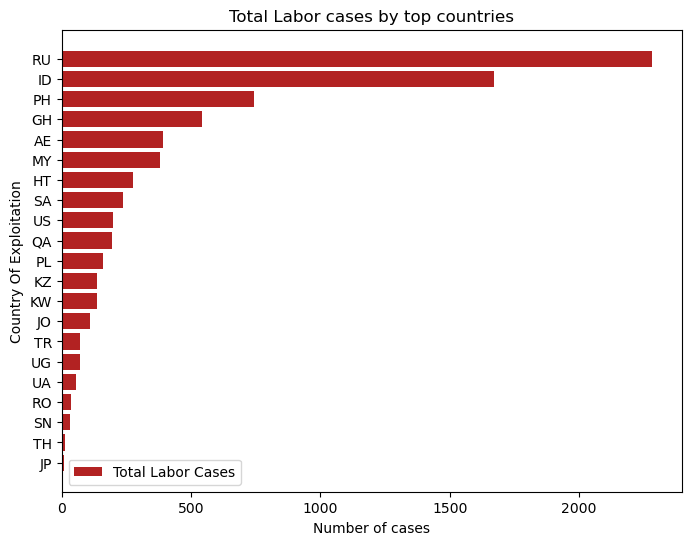

In [27]:
# Graph: number of sexual explotation in the US
df_aux = df_ctdc_top_30_countries.copy()
df_aux = df_aux.sort_values(by='n_forced_labour')
df_aux = df_aux[df_aux['n_forced_labour'] != 0]
plt.figure(figsize=(8, 6)) 
plt.barh(df_aux['CountryOfExploitation'], df_aux['n_forced_labour'], color='firebrick', label='Total Labor Cases')
# Add labels and title
plt.title('Total Labor cases by top countries')
plt.xlabel('Number of cases')
plt.ylabel('Country Of Exploitation')
plt.legend()
plt.show()

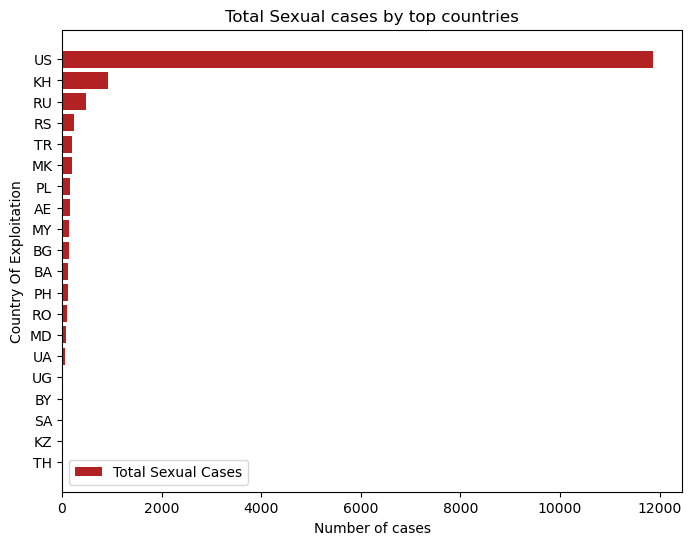

In [28]:
# Graph: number of sexual explotation in the US
df_aux = df_ctdc_top_30_countries.copy()
df_aux = df_aux[df_aux['n_sexual_exploit'] != 0]
df_aux = df_aux.sort_values(by='n_sexual_exploit')
plt.figure(figsize=(8, 6)) 
plt.barh(df_aux['CountryOfExploitation'], df_aux['n_sexual_exploit'], color='firebrick', label='Total Sexual Cases')
# Add labels and title
plt.title('Total Sexual cases by top countries')
plt.xlabel('Number of cases')
plt.ylabel('Country Of Exploitation')
plt.legend()
plt.show()

**Top Age and gender:**

In [29]:
df_ctdc_age_gender.head(10)

,ageBroad,gender,n,n_forced_labour,n_sexual_exploit,n_forced_labour_obs,n_sexual_exploit_obs
0,0--8,Female,841,101,122,223,211
1,0--8,Male,715,121,36,157,157
2,18--20,Female,4227,256,2906,3237,3238
3,18--20,Male,221,90,30,120,120
4,21--23,Female,3734,211,2325,2660,2635
5,21--23,Male,479,264,25,289,289
6,24--26,Female,2816,174,1551,1854,1854
7,24--26,Male,648,347,17,364,364
8,27--29,Female,1869,227,891,1144,1118
9,27--29,Male,772,416,0,416,403


## 4. Global Dataset

In [30]:
# Drop the first column 
df_global_dataset.drop('By using this data you agree to the Terms of Use: https://www.ctdatacollaborative.org/terms-use', axis=1, inplace=True)

In [31]:
print('shape:', df_global_dataset.shape)
df_global_dataset.head(5)

shape: (48801, 63)


,yearOfRegistration,Datasource,gender,ageBroad,majorityStatus,majorityStatusAtExploit,majorityEntry,citizenship,meansOfControlDebtBondage,meansOfControlTakesEarnings,...,typeOfSexPrivateSexualServices,typeOfSexConcatenated,isAbduction,RecruiterRelationship,CountryOfExploitation,recruiterRelationIntimatePartner,recruiterRelationFriend,recruiterRelationFamily,recruiterRelationOther,recruiterRelationUnknown
0,2002,Case Management,Female,18--20,Adult,-99,-99,CO,-99,-99,...,-99,-99,-99,-99,-99,0,0,0,0,1
1,2002,Case Management,Female,18--20,Adult,-99,-99,CO,-99,-99,...,-99,-99,-99,-99,-99,0,0,0,0,1
2,2002,Case Management,Female,18--20,Adult,-99,-99,CO,-99,-99,...,-99,-99,-99,-99,-99,0,0,0,0,1
3,2002,Case Management,Female,18--20,Adult,-99,-99,CO,-99,-99,...,-99,-99,-99,-99,-99,0,0,0,0,1
4,2002,Case Management,Female,18--20,Adult,-99,-99,CO,-99,-99,...,-99,-99,-99,-99,-99,0,0,0,0,1


In [32]:
df_global_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 48801 entries, 0 to 48800
Data columns (total 63 columns):
 #   Column                                  Non-Null Count  Dtype
---  ------                                  --------------  -----
 0   yearOfRegistration                      48801 non-null  int64
 1   Datasource                              48801 non-null  str  
 2   gender                                  48801 non-null  str  
 3   ageBroad                                48801 non-null  str  
 4   majorityStatus                          48801 non-null  str  
 5   majorityStatusAtExploit                 48801 non-null  str  
 6   majorityEntry                           48801 non-null  str  
 7   citizenship                             48801 non-null  str  
 8   meansOfControlDebtBondage               48801 non-null  int64
 9   meansOfControlTakesEarnings             48801 non-null  int64
 10  meansOfControlRestrictsFinancialAccess  48801 non-null  int64
 11  meansOfControlThreats     

In [33]:
# Eliminate the columns that have all missing values
total_rows = df_global_dataset.shape[0]
list_total_missing_values = []
list_percentage_missing_values = []
list_drop_columns = []

# Check if all number of values in of a column are -99 or '-99'
for col in df_global_dataset.columns:
    # Calculate missing values
    total_missing_value = np.sum((df_global_dataset[col]=='-99') | (df_global_dataset[col]==-99) )
    percentage_missing_value = total_missing_value / total_rows
    list_total_missing_values.append(total_missing_value)
    list_percentage_missing_values.append(percentage_missing_value)


# Check missing values by rows and percentage
df_missing = pd.DataFrame({'column_name': df_global_dataset.columns, 'missing_value': list_total_missing_values,'%missing_value': list_percentage_missing_values})
# Filer columns without missing values
df_missing = df_missing[df_missing['missing_value'] > 0]
# Sort by missing values
df_missing = df_missing.sort_values(by='missing_value', ascending=False)
display(df_missing)

,column_name,missing_value,%missing_value
20,meansOfControlUsesChildren,48650,0.996906
10,meansOfControlRestrictsFinancialAccess,48548,0.994816
34,isSlaveryAndPractices,47213,0.967460
21,meansOfControlThreatOfLawEnforcement,46793,0.958853
8,meansOfControlDebtBondage,46305,0.948854
18,meansOfControlRestrictsMedicalCare,46302,0.948792
22,meansOfControlWithholdsNecessities,46217,0.947050
14,meansOfControlSexualAbuse,45980,0.942194
24,meansOfControlOther,45701,0.936477
23,meansOfControlWithholdsDocuments,45527,0.932911


In [34]:
# Eliminate columns that have a 90% of more misiing values
df_aux = df_missing[df_missing['%missing_value'] >= 0.9]
list_drop_columns = df_aux['column_name'].values.tolist()
print('Amount of columns to be drop: ', len(list_drop_columns))
print('Name of columns to be drop: ', list_drop_columns)
# Drop columns
df_global_dataset.drop(list_drop_columns,axis=1, inplace=True)
df_missing = df_missing[df_missing['%missing_value'] < 0.9]

Amount of columns to be drop:  16
Name of columns to be drop:  ['meansOfControlUsesChildren', 'meansOfControlRestrictsFinancialAccess', 'isSlaveryAndPractices', 'meansOfControlThreatOfLawEnforcement', 'meansOfControlDebtBondage', 'meansOfControlRestrictsMedicalCare', 'meansOfControlWithholdsNecessities', 'meansOfControlSexualAbuse', 'meansOfControlOther', 'meansOfControlWithholdsDocuments', 'meansOfControlExcessiveWorkingHours', 'meansOfControlPsychoactiveSubstances', 'meansOfControlFalsePromises', 'meansOfControlTakesEarnings', 'typeOfSexConcatenated', 'meansOfControlPhysicalAbuse']


In [35]:
# Check the number of years
print('Number of years in the dataset: ',df_global_dataset['yearOfRegistration'].nunique())
print('Years: ',df_global_dataset['yearOfRegistration'].unique() )

# add count variable
df_global_dataset['count'] = 1

Number of years in the dataset:  18
Years:  [2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015
 2016 2017 2018 2019]


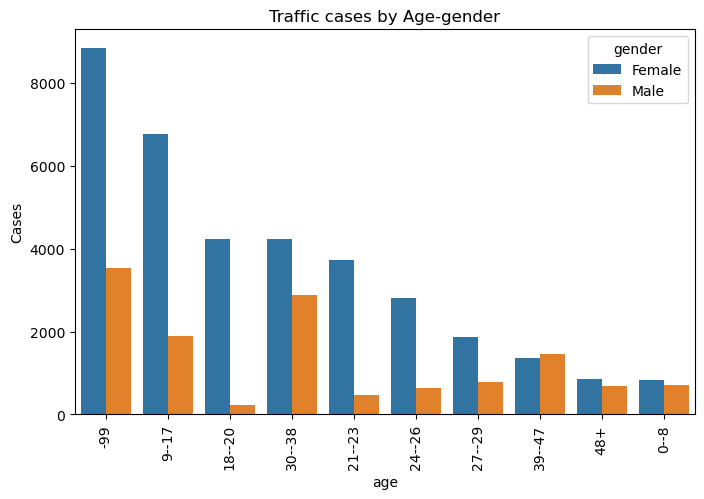

In [36]:
# Create datasets
df_gender_age = df_global_dataset.groupby(['gender','ageBroad'])['count'].agg(['count']).reset_index()
df_gender_age = df_gender_age.sort_values(by='count', ascending=False)
# barplot
plt.figure(figsize=(8,5))
sns.barplot(x="ageBroad", y="count",hue='gender', data=df_gender_age)
plt.title(f'Traffic cases by Age-gender')
plt.xlabel('age')
plt.ylabel('Cases')
plt.xticks(rotation=90)
plt.show()


The pie chart shows that 72.8% of human traffic is female. Taking a closer look, by age, the most affected are 9-17 and 18-20 year olds, the most likely target victims are teenagers and young adults. In the case of Men, they represents 27% of the human trafficking cases, and the most frequent age group is 18-20 years old.

Feature: gender


,gender,count_cases,percentage_cases
0,Female,35534,0.73
1,Male,13267,0.27


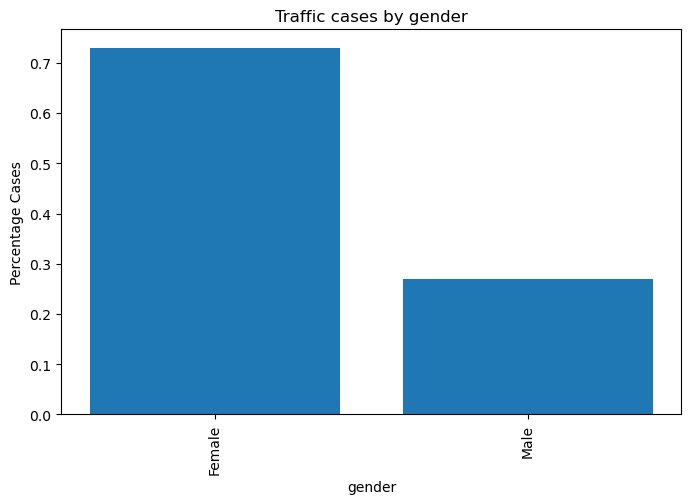

Feature: ageBroad


,ageBroad,count_cases,percentage_cases
0,-99,12362,0.25
9,9--17,8645,0.18
6,30--38,7091,0.15
2,18--20,4448,0.09
3,21--23,4213,0.09
4,24--26,3464,0.07
7,39--47,2821,0.06
5,27--29,2641,0.05
8,48+,1560,0.03
1,0--8,1556,0.03


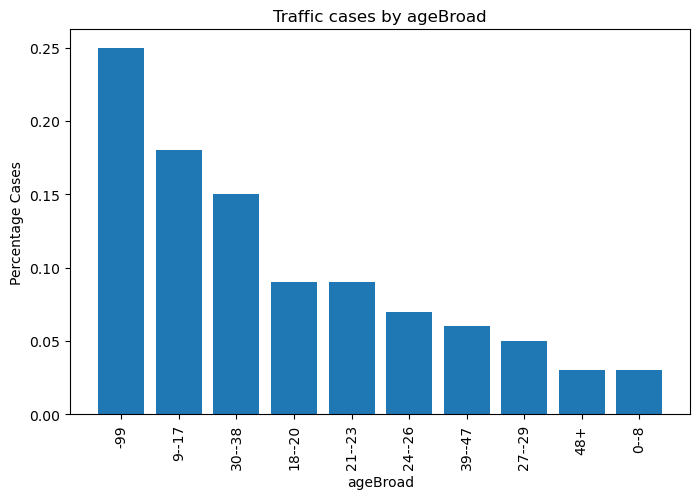

Feature: majorityStatus


,majorityStatus,count_cases,percentage_cases
1,Adult,26238,0.54
0,-99,12362,0.25
2,Minor,10201,0.21


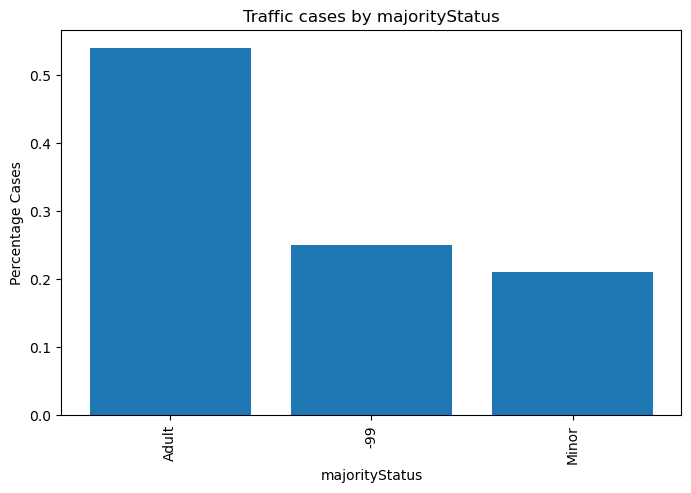

Feature: majorityStatusAtExploit


,majorityStatusAtExploit,count_cases,percentage_cases
0,-99,39511,0.81
2,Minor,7044,0.14
1,Adult,2246,0.05


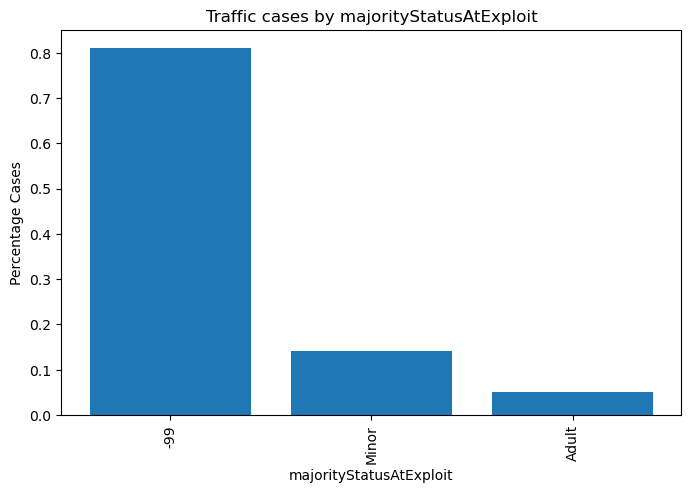

Feature: citizenship


,citizenship,count_cases,percentage_cases
34,PH,11365,0.23
1,00,8858,0.18
41,UA,7761,0.16
26,MD,5901,0.12
43,US,3636,0.07
21,KH,1979,0.04
18,ID,1971,0.04
8,BY,1463,0.03
29,MM,1250,0.03
35,RO,655,0.01


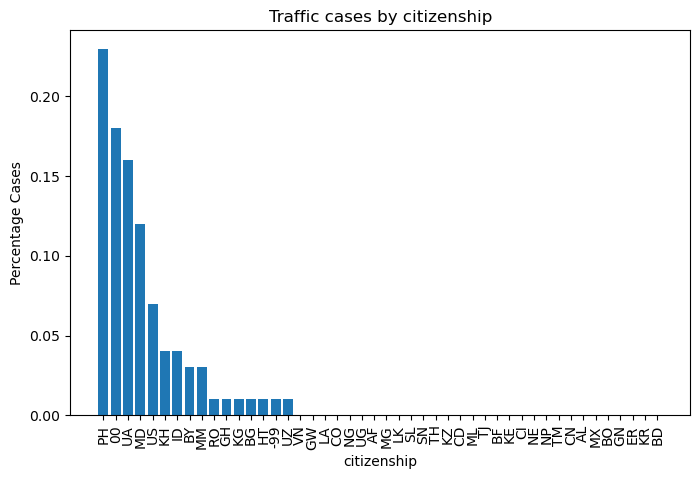

Feature: isForcedLabour


,isForcedLabour,count_cases,percentage_cases
0,-99,22699,0.47
1,0,16330,0.33
2,1,9772,0.20


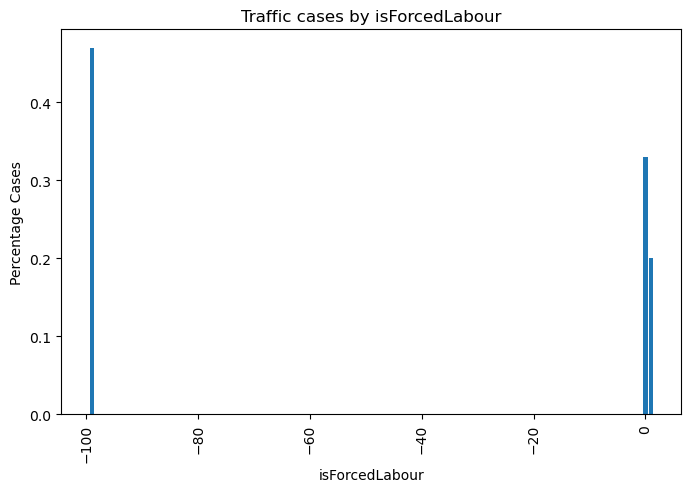

Feature: isSexualExploit


,isSexualExploit,count_cases,percentage_cases
0,-99,24940,0.51
2,1,16067,0.33
1,0,7794,0.16


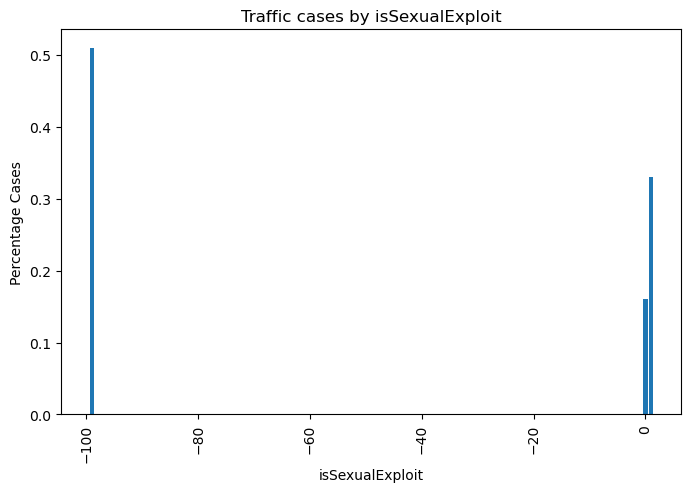

Feature: isOtherExploit


,isOtherExploit,count_cases,percentage_cases
1,0,23874,0.49
0,-99,17863,0.37
2,1,7064,0.14


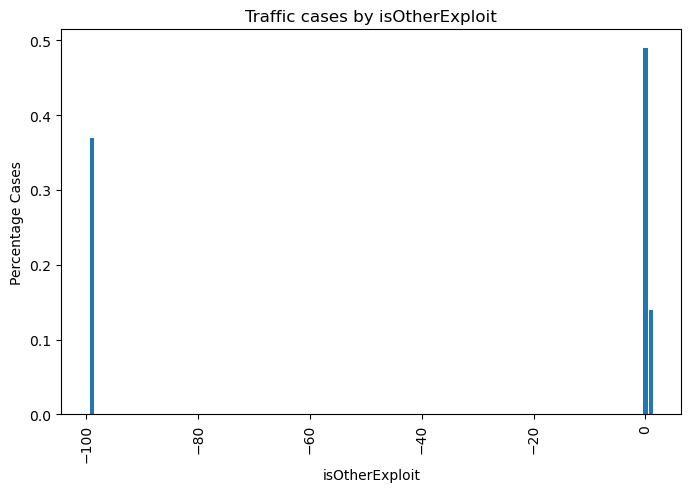

Feature: isSexAndLabour


,isSexAndLabour,count_cases,percentage_cases
0,-99,25345,0.52
1,0,23378,0.48
2,1,78,0.00


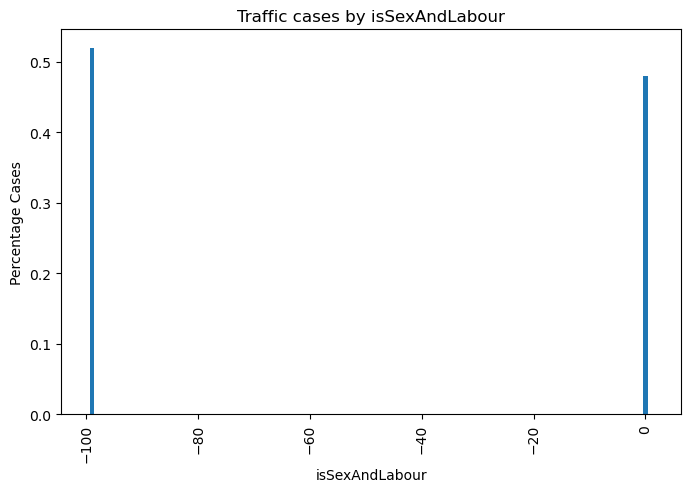

Feature: isForcedMarriage


,isForcedMarriage,count_cases,percentage_cases
0,-99,37775,0.77
1,0,10858,0.22
2,1,168,0.00


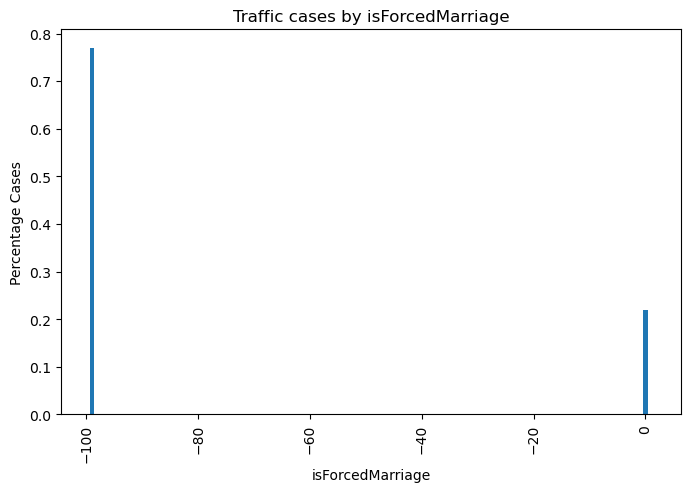

Feature: isForcedMilitary


,isForcedMilitary,count_cases,percentage_cases
0,-99,37351,0.77
1,0,11450,0.23


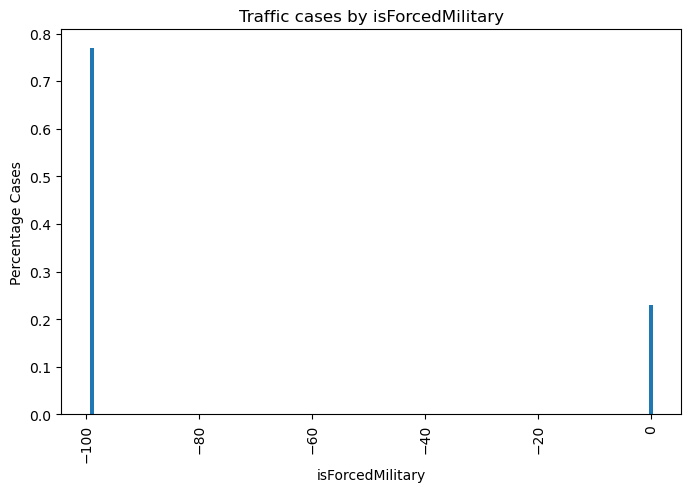

Feature: isOrganRemoval


,isOrganRemoval,count_cases,percentage_cases
0,-99,37351,0.77
1,0,11450,0.23


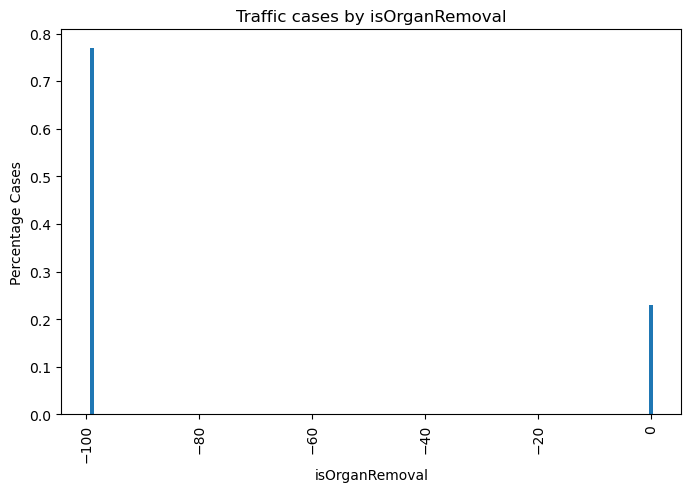

Feature: isAbduction


,isAbduction,count_cases,percentage_cases
0,-99,32430,0.66
1,0,16332,0.33
2,1,39,0.00


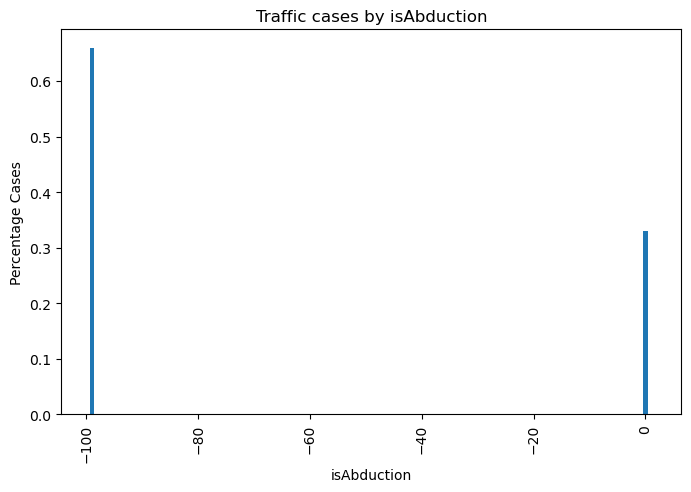

In [37]:
# Quick check categorical variables

categorical_features = ['gender','ageBroad','majorityStatus','majorityStatusAtExploit','citizenship','isForcedLabour', 'isSexualExploit', 'isOtherExploit', 'isSexAndLabour',
       'isForcedMarriage', 'isForcedMilitary', 'isOrganRemoval','isAbduction' ]

for feature in categorical_features:
    print("Feature:", feature)
    # Create summary table for the feature and the target variable
    df_aux = df_global_dataset.groupby(feature)['count'].agg(['count']).reset_index()
    df_aux.rename(columns={'count': 'count_cases'}, inplace=True)
    total_cases = np.sum(df_aux['count_cases'])
    df_aux['percentage_cases'] = round(df_aux['count_cases']/total_cases,2)
    df_aux = df_aux.sort_values(by='count_cases', ascending=False)
    display(df_aux)
    # Show graph
    plt.figure(figsize=(8,5))
    plt.bar(df_aux[feature], df_aux['percentage_cases'])
    plt.title(f'Traffic cases by {feature}')
    plt.xlabel(feature)
    plt.ylabel('Percentage Cases')
    plt.xticks(rotation=90)
    plt.show()

Feature: typeOfExploitConcatenated


,typeOfExploitConcatenated,count_cases,percentage_cases
0,-99,16174,0.33
6,Sexual exploitation,15989,0.33
1,Forced labour,8969,0.18
5,Other,7063,0.14
7,Slavery and similar practices,359,0.01
4,Forced marriage,168,0.00
3,Forced labour;Sexual exploitation;Combined sex...,78,0.00
2,Forced labour;Other,1,0.00


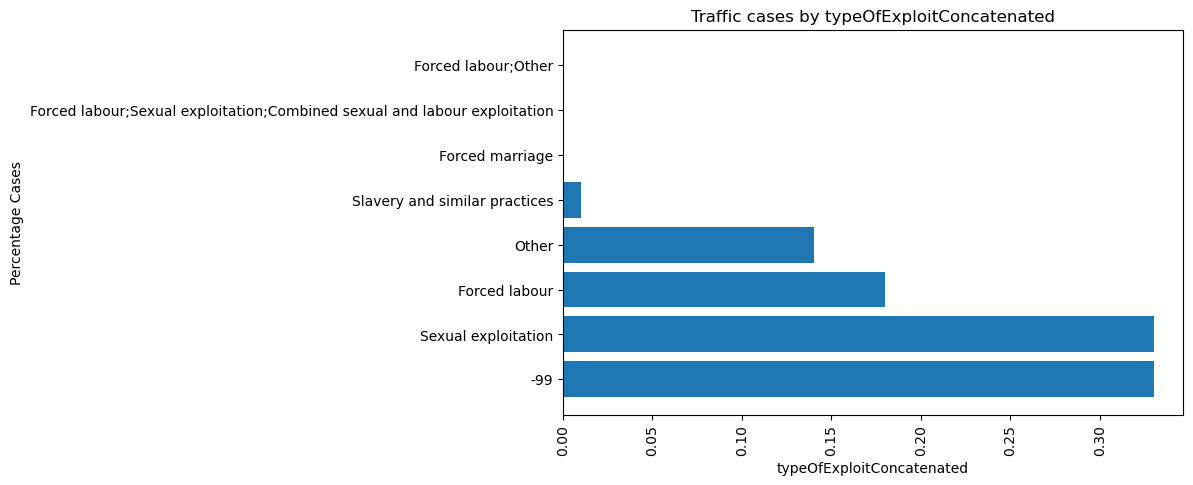

Feature: typeOfLabourAgriculture


,typeOfLabourAgriculture,count_cases,percentage_cases
0,-99,28329,0.58
1,0,20320,0.42
2,1,152,0.00


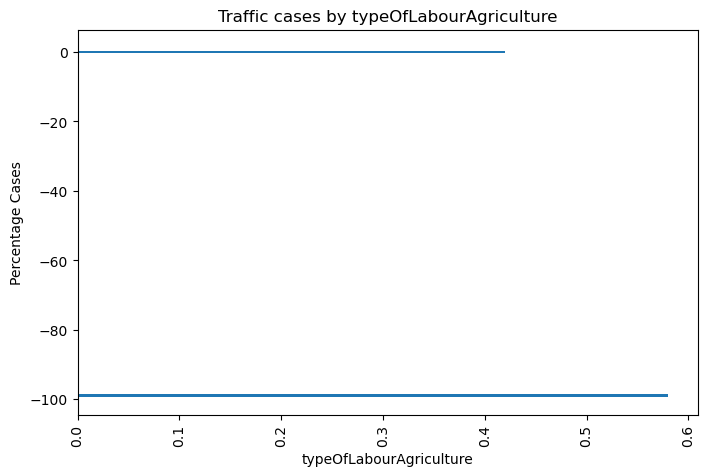

Feature: typeOfLabourAquafarming


,typeOfLabourAquafarming,count_cases,percentage_cases
0,-99,28368,0.58
1,0,20326,0.42
2,1,107,0.00


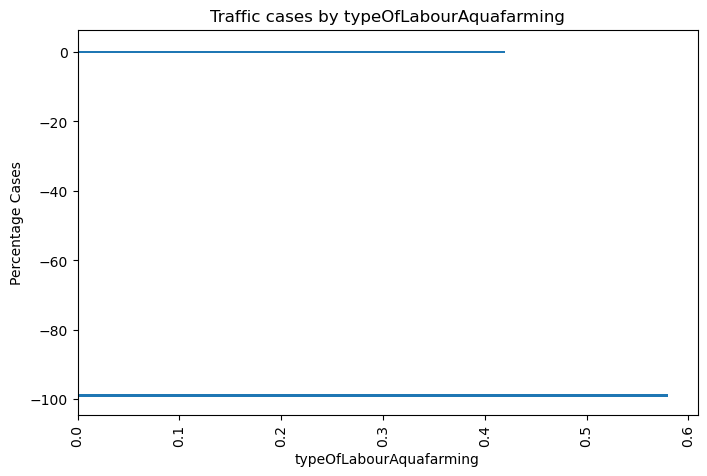

Feature: typeOfLabourBegging


,typeOfLabourBegging,count_cases,percentage_cases
0,-99,28381,0.58
1,0,20271,0.42
2,1,149,0.00


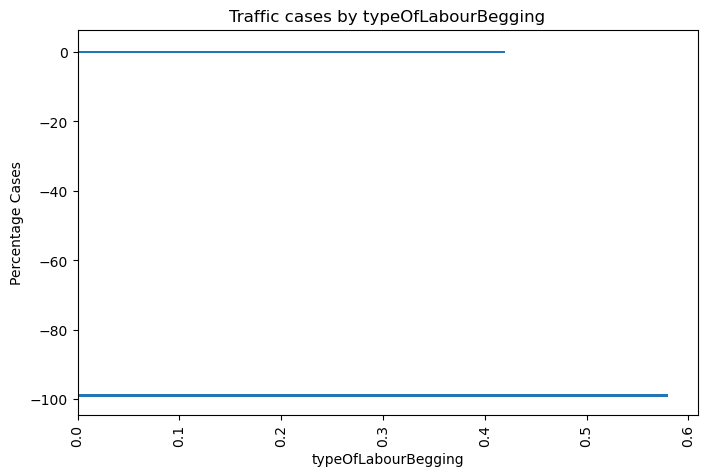

Feature: typeOfLabourConstruction


,typeOfLabourConstruction,count_cases,percentage_cases
0,-99,28001,0.57
1,0,19546,0.40
2,1,1254,0.03


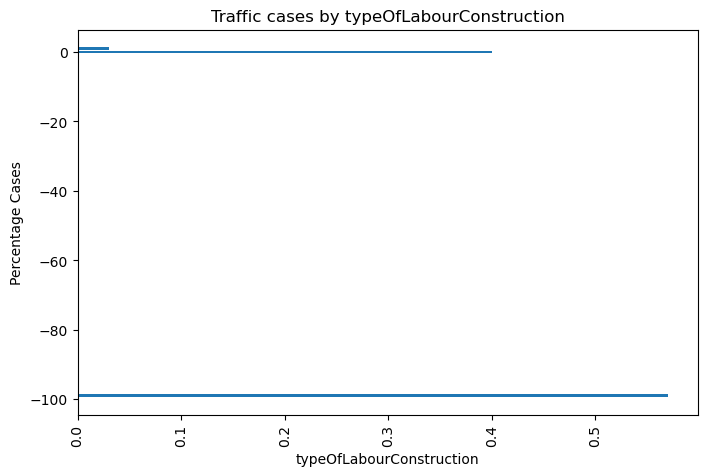

Feature: typeOfLabourDomesticWork


,typeOfLabourDomesticWork,count_cases,percentage_cases
0,-99,26250,0.54
1,0,19807,0.41
2,1,2744,0.06


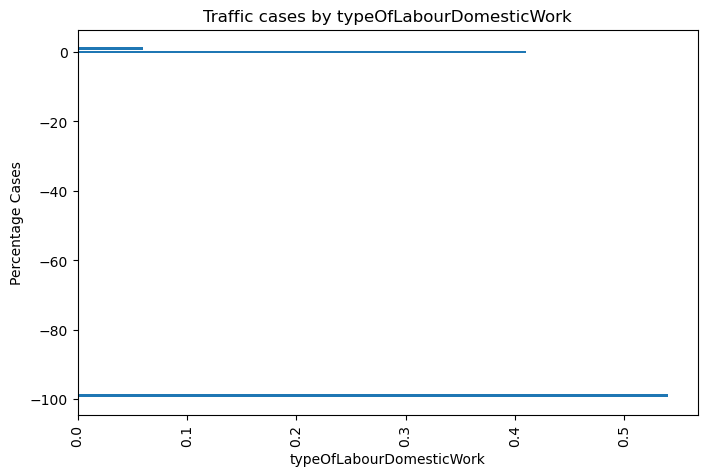

Feature: typeOfLabourHospitality


,typeOfLabourHospitality,count_cases,percentage_cases
0,-99,27120,0.56
1,0,21599,0.44
2,1,82,0.00


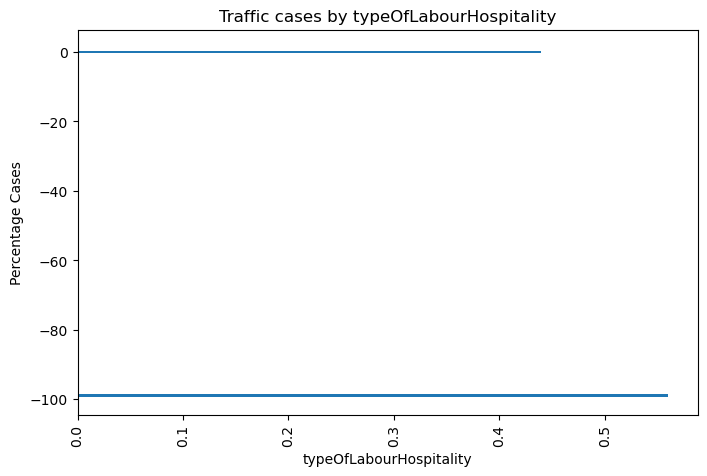

Feature: typeOfLabourIllicitActivities


,typeOfLabourIllicitActivities,count_cases,percentage_cases
0,-99,28459,0.58
1,0,20342,0.42


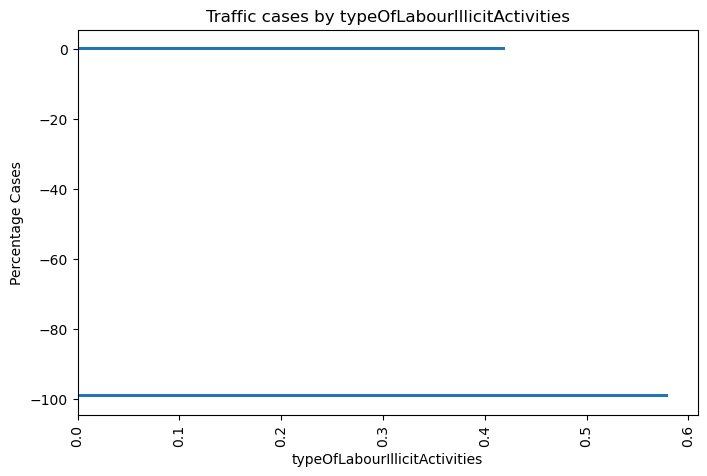

Feature: typeOfLabourManufacturing


,typeOfLabourManufacturing,count_cases,percentage_cases
0,-99,28256,0.58
1,0,20092,0.41
2,1,453,0.01


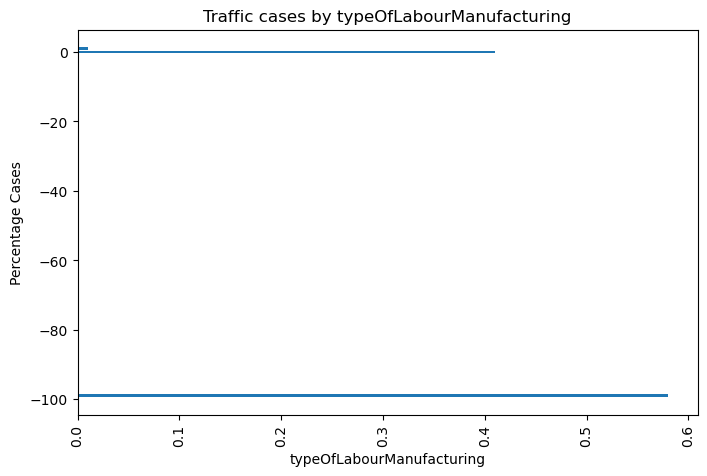

Feature: typeOfLabourMiningOrDrilling


,typeOfLabourMiningOrDrilling,count_cases,percentage_cases
0,-99,28381,0.58
1,0,20420,0.42


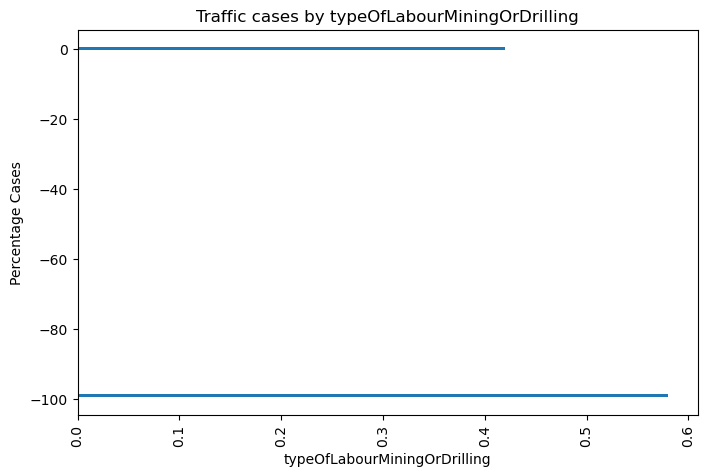

Feature: typeOfLabourPeddling


,typeOfLabourPeddling,count_cases,percentage_cases
0,-99,28459,0.58
1,0,20270,0.42
2,1,72,0.00


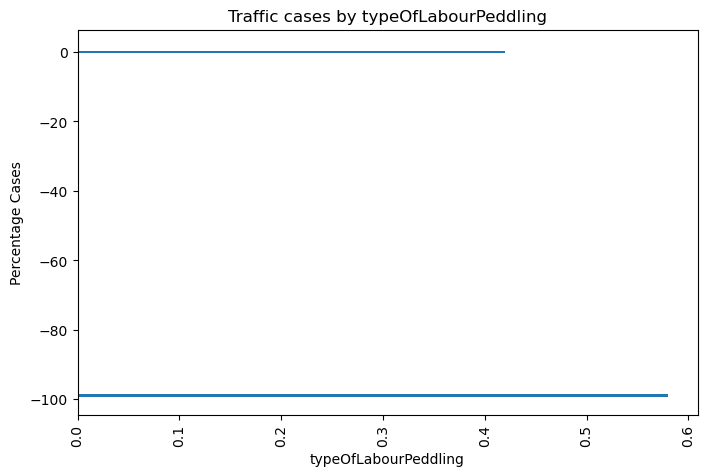

Feature: typeOfLabourTransportation


,typeOfLabourTransportation,count_cases,percentage_cases
0,-99,28381,0.58
1,0,20420,0.42


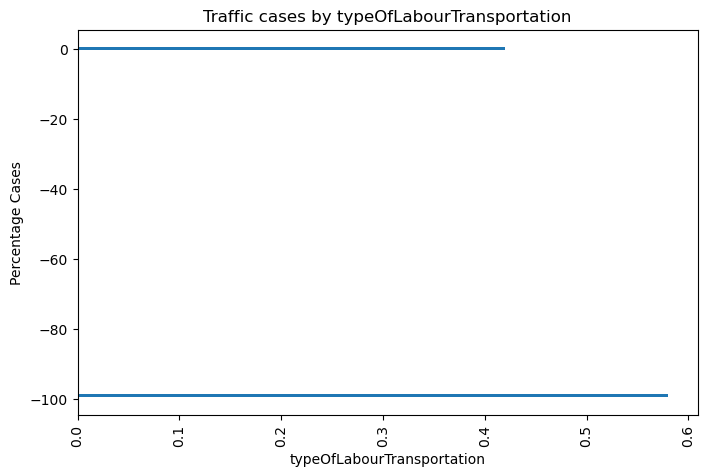

Feature: typeOfLabourOther


,typeOfLabourOther,count_cases,percentage_cases
0,-99,27117,0.56
1,0,21523,0.44
2,1,161,0.00


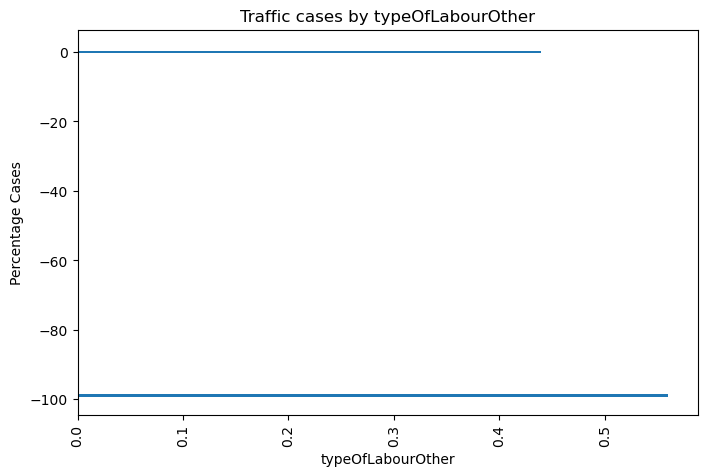

Feature: typeOfLabourNotSpecified


,typeOfLabourNotSpecified,count_cases,percentage_cases
0,-99,27179,0.56
1,0,20451,0.42
2,1,1171,0.02


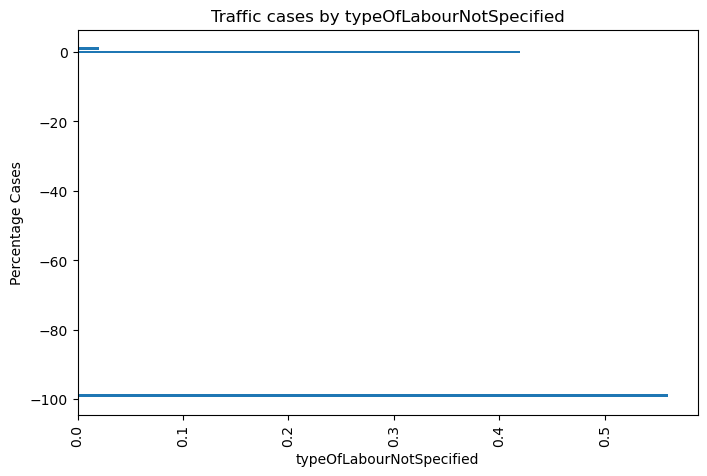

Feature: typeOfLabourConcatenated


,typeOfLabourConcatenated,count_cases,percentage_cases
0,-99,42552,0.87
7,Domestic work,2721,0.06
5,Construction,1251,0.03
12,Not specified,1097,0.02
11,Manufacturing,453,0.01
1,Agriculture,149,0.00
4,Begging,149,0.00
3,Aquafarming,107,0.00
10,Hospitality,82,0.00
13,Other,77,0.00


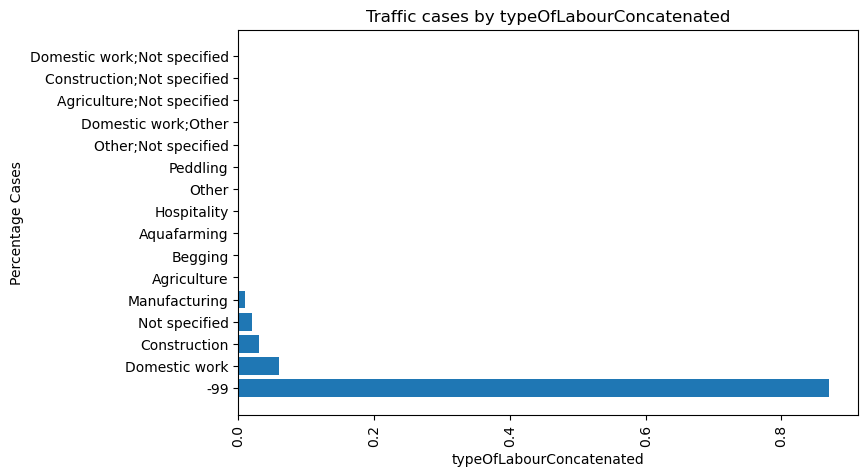

Feature: typeOfSexProstitution


,typeOfSexProstitution,count_cases,percentage_cases
0,-99,30343,0.62
1,0,14072,0.29
2,1,4386,0.09


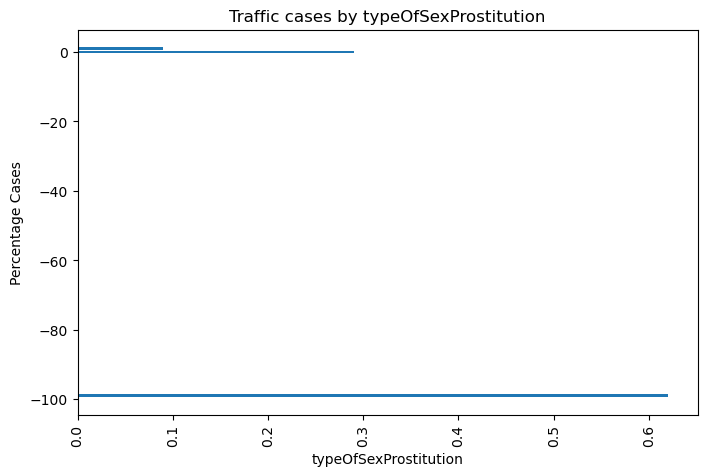

Feature: typeOfSexPornography


,typeOfSexPornography,count_cases,percentage_cases
0,-99,42357,0.87
1,0,6284,0.13
2,1,160,0.00


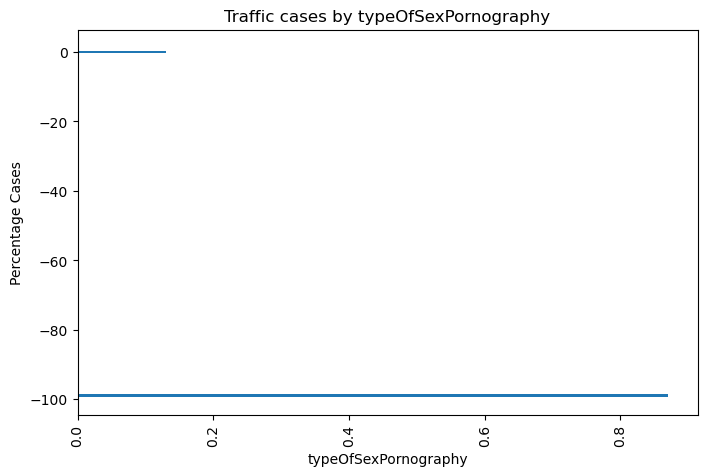

Feature: typeOfSexRemoteInteractiveServices


,typeOfSexRemoteInteractiveServices,count_cases,percentage_cases
0,-99,42357,0.87
1,0,6444,0.13


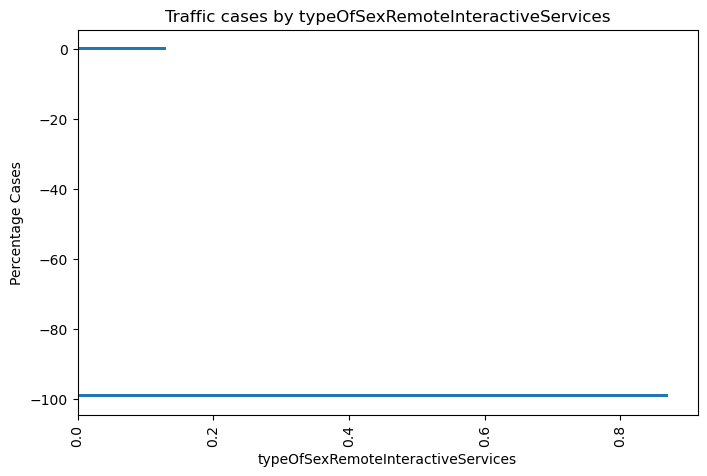

Feature: typeOfSexPrivateSexualServices


,typeOfSexPrivateSexualServices,count_cases,percentage_cases
0,-99,43586,0.89
1,0,5172,0.11
2,1,43,0.00


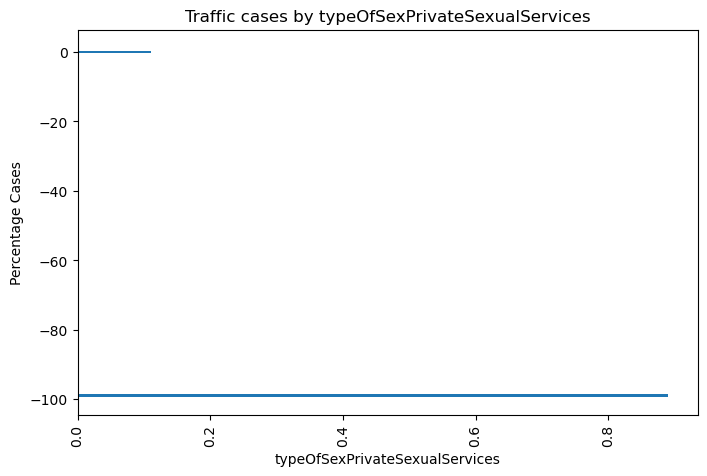

In [38]:
type_features = ['typeOfExploitConcatenated', 'typeOfLabourAgriculture',
       'typeOfLabourAquafarming', 'typeOfLabourBegging',
       'typeOfLabourConstruction', 'typeOfLabourDomesticWork',
       'typeOfLabourHospitality', 'typeOfLabourIllicitActivities',
       'typeOfLabourManufacturing', 'typeOfLabourMiningOrDrilling',
       'typeOfLabourPeddling', 'typeOfLabourTransportation',
       'typeOfLabourOther', 'typeOfLabourNotSpecified',
       'typeOfLabourConcatenated', 'typeOfSexProstitution',
       'typeOfSexPornography', 'typeOfSexRemoteInteractiveServices',
       'typeOfSexPrivateSexualServices']
for feature in type_features:
    print("Feature:", feature)
    # Create summary table for the feature and the target variable
    df_aux = df_global_dataset.groupby(feature)['count'].agg(['count']).reset_index()
    df_aux.rename(columns={'count': 'count_cases'}, inplace=True)
    total_cases = np.sum(df_aux['count_cases'])
    df_aux['percentage_cases'] = round(df_aux['count_cases']/total_cases,2)
    df_aux = df_aux.sort_values(by='count_cases', ascending=False)
    display(df_aux)
    # Show graph
    plt.figure(figsize=(8,5))
    plt.barh(df_aux[feature], df_aux['percentage_cases'])
    plt.title(f'Traffic cases by {feature}')
    plt.xlabel(feature)
    plt.ylabel('Percentage Cases')
    plt.xticks(rotation=90)
    plt.show()